In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import normalize

In [2]:
# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Print dataset shapes
print(f"Training Data Shape: {x_train.shape}")
print(f"Testing Data Shape: {x_test.shape}")

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


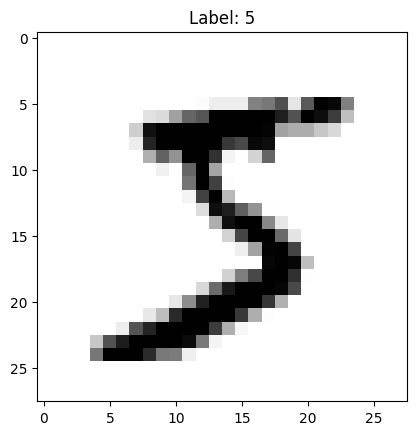

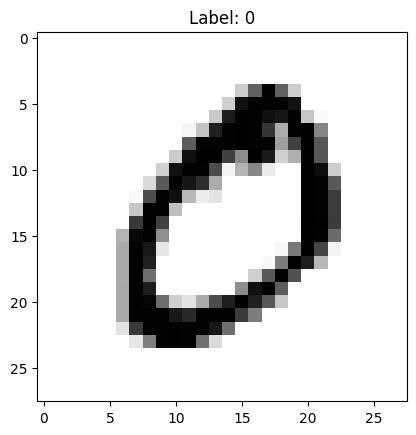

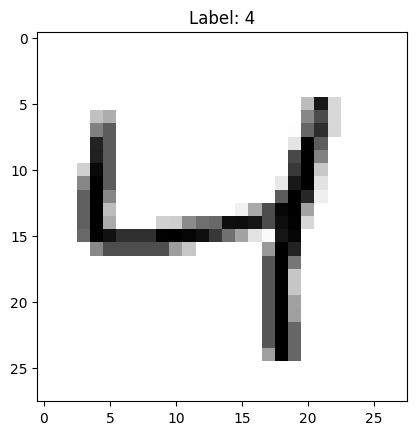

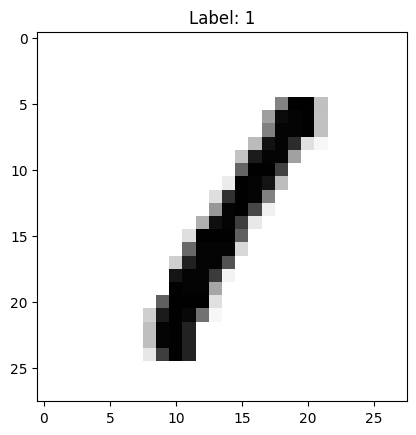

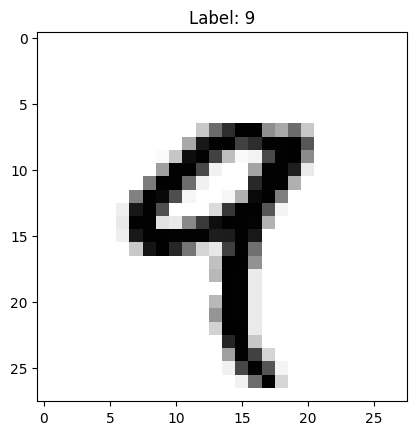

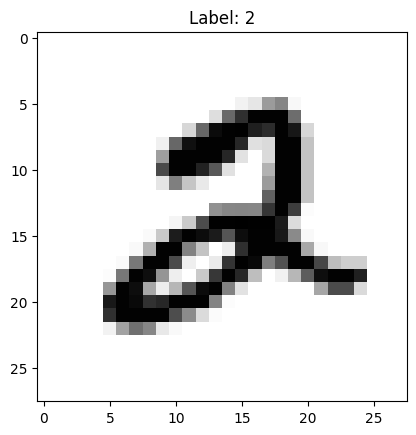

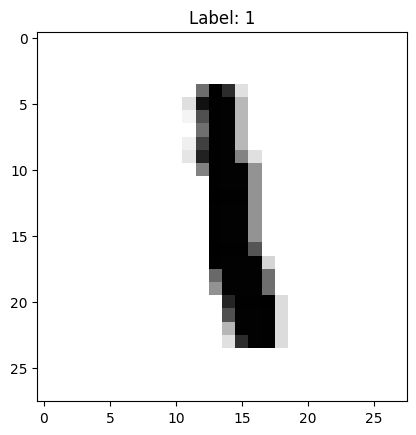

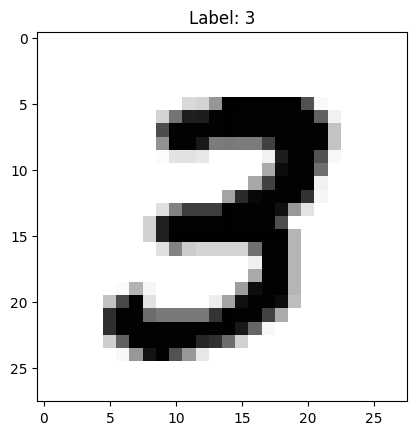

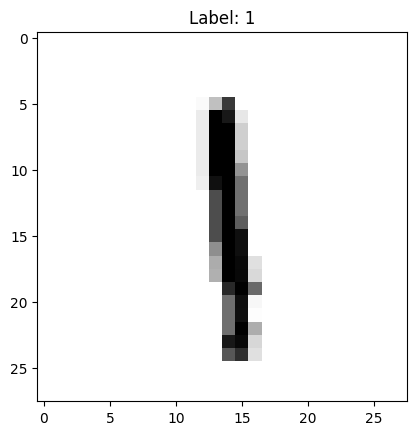

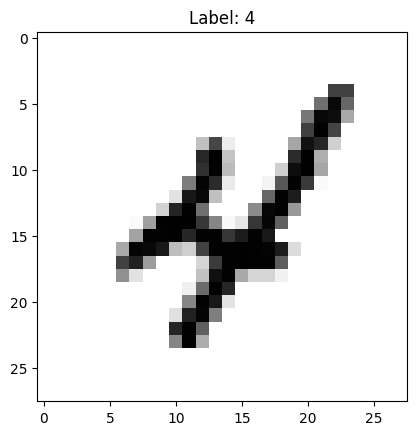

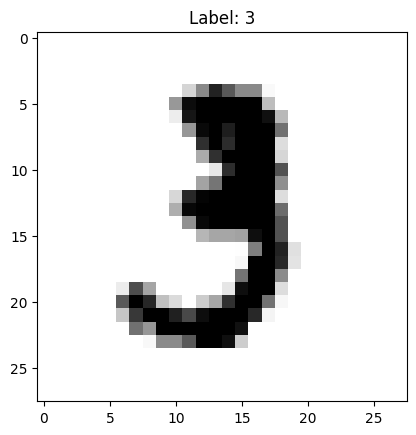

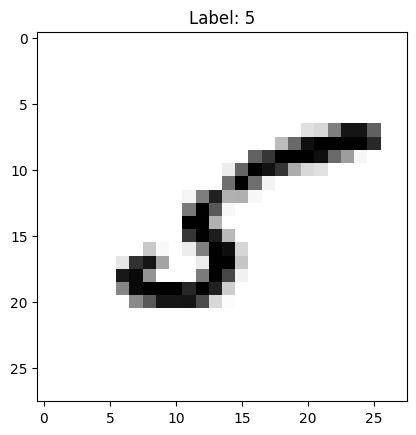

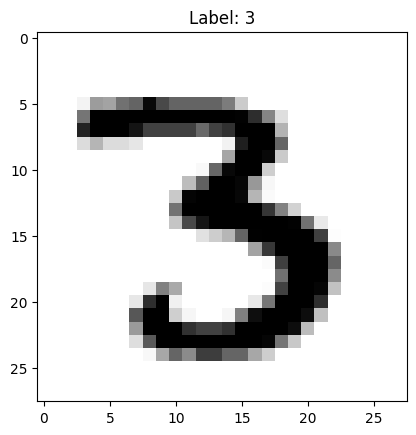

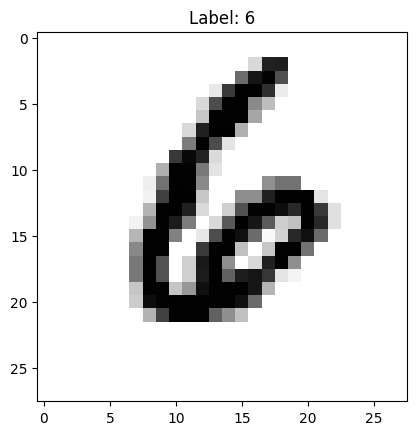

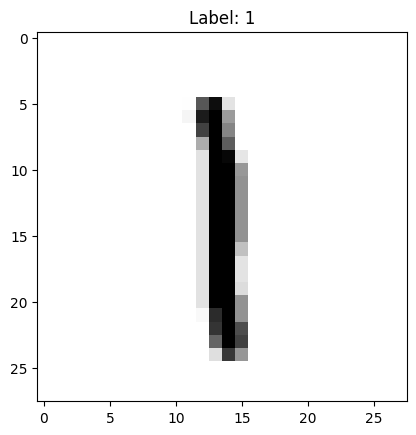

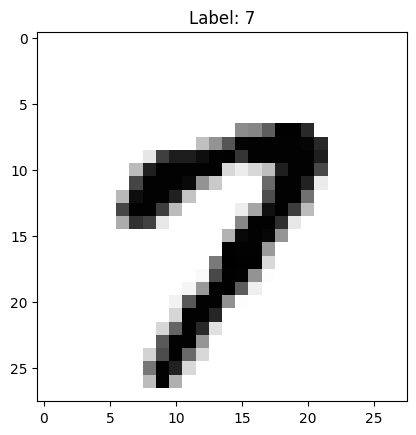

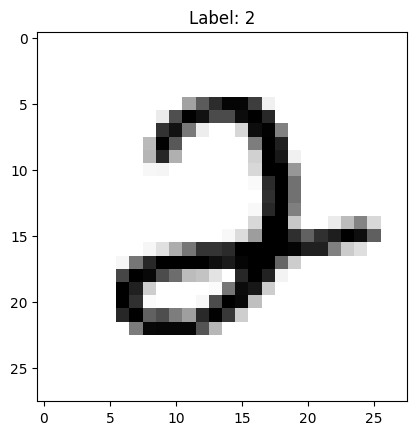

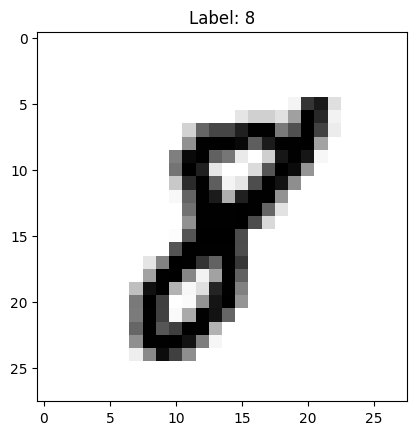

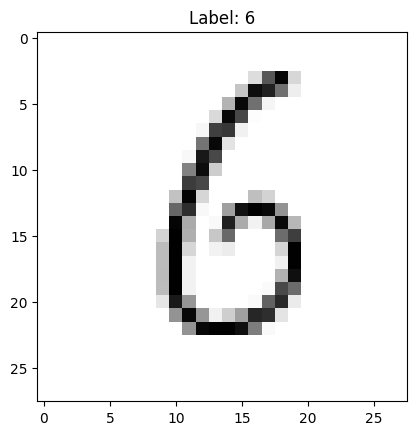

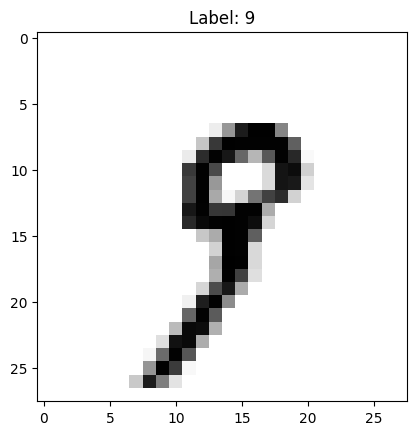

In [4]:
# Display sample images
for i in range(0, 20):
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.title(f"Label: {y_train[i]}")
    plt.show()

In [5]:
# Reshape dataset for CNN input (28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
# Normalize pixel values to range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
# Build CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # Output layer (10 digits)
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
# Train Model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9119 - loss: 0.2941 - val_accuracy: 0.9840 - val_loss: 0.0495
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9858 - loss: 0.0442 - val_accuracy: 0.9886 - val_loss: 0.0352
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9916 - loss: 0.0290 - val_accuracy: 0.9894 - val_loss: 0.0343
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9938 - loss: 0.0195 - val_accuracy: 0.9886 - val_loss: 0.0373
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9946 - loss: 0.0165 - val_accuracy: 0.9915 - val_loss: 0.0277


In [10]:
# Evaluate Model
val_loss, val_acc = model.evaluate(x_test, y_test)
print(f"Test Loss: {val_loss}, Test Accuracy: {val_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9895 - loss: 0.0320
Test Loss: 0.027740100398659706, Test Accuracy: 0.9915000200271606


In [11]:
# ======================== #
#  📸 Webcam Capture Code  #
# ======================== #

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function take_photo(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize the output to fit the video element
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Wait for Capture to be clicked
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('take_photo({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


<IPython.core.display.Javascript object>

Saved to photo.jpg


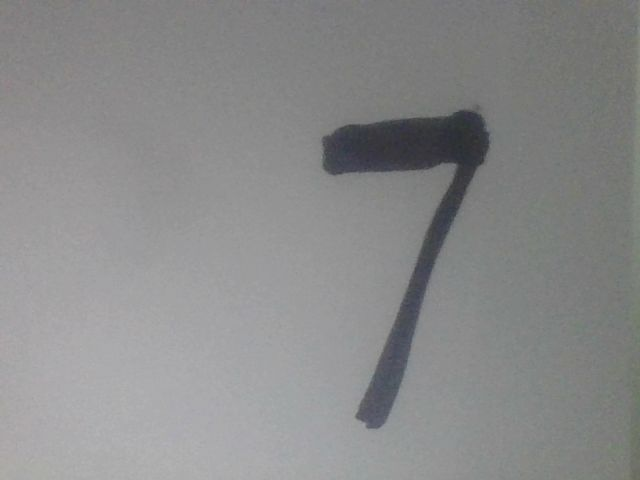

In [70]:
# Try capturing an image from webcam
from IPython.display import Image
try:
    filename = take_photo()
    print(f"Saved to {filename}")
    display(Image(filename))
except Exception as err:
    print(f"Webcam Error: {str(err)}")

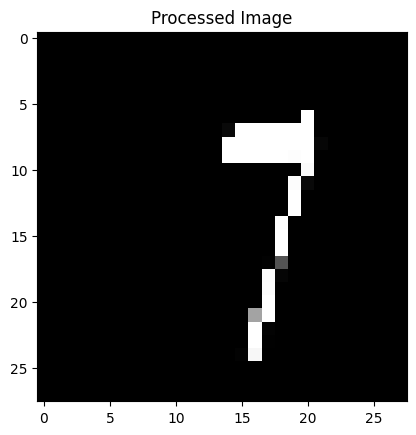

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Probability distribution:
Digit 0: 0.0000
Digit 1: 0.0005
Digit 2: 0.0002
Digit 3: 0.0001
Digit 4: 0.0001
Digit 5: 0.0002
Digit 6: 0.0000
Digit 7: 0.9987
Digit 8: 0.0001
Digit 9: 0.0002
The Predicted Value is 7


In [71]:
from PIL import Image

# Load user image
user_img = Image.open(filename)

# Convert to grayscale
gray_img = user_img.convert('L')

# Binarization (Thresholding)
bw_img = gray_img.point(lambda x: 0 if x < 100 else 255, '1')
bw_img.save("bw_image.jpg")

# Read processed image with OpenCV
img_array = cv2.imread("bw_image.jpg", cv2.IMREAD_GRAYSCALE)

# Invert colors (White -> Black, Black -> White)
img_array = cv2.bitwise_not(img_array)

# Resize image to 28x28
img_resized = cv2.resize(img_array, (28, 28))

# Show the processed image
plt.imshow(img_resized, cmap='gray')
plt.title("Processed Image")
plt.show()

# Normalize and Reshape
user_test = img_resized / 255.0  # Normalize to [0, 1]
user_test = user_test.reshape(1, 28, 28, 1)  # Reshape for model input

# Predict digit
predicted = model.predict(user_test)

# Print probabilities
print("Probability distribution:")
for i in range(10):
    print(f"Digit {i}: {predicted[0][i]:.4f}")

# Show final prediction
print(f"The Predicted Value is {np.argmax(predicted[0])}")
